# Inferential Statistics for Machine Learning — Concepts & Code

This notebook is the hands-on companion to **`Inferential_Statistics.docx`**. Every concept explained in that document is demonstrated here with runnable Python code, using NumPy, SciPy, Pandas, and Matplotlib.

## Learning Objectives
- Simulate the difference between a population and a sample.
- Demonstrate the Central Limit Theorem directly through simulation.
- Compute standard error.
- Work with the Normal distribution and the empirical rule.
- Build and interpret confidence intervals.
- Run hypothesis tests: one-sample and two-sample t-tests, chi-square, and ANOVA.
- Demonstrate correlation vs causation with a simulated confounding variable.

## Prerequisites
- `Descriptive_Statistics.docx` and `Descriptive_Statistics_Concepts_and_Code.ipynb`.
- Read `Inferential_Statistics.docx` first for the plain-English explanations behind the code below.

---
## Table of Contents
1. [Setup](#setup)
2. [Population vs Sample](#population-sample)
3. [Central Limit Theorem](#clt)
4. [Standard Error](#standard-error)
5. [Normal Distribution and the Empirical Rule](#normal)
6. [Confidence Intervals](#confidence-intervals)
7. [Hypothesis Testing](#hypothesis-testing)
8. [Z-Test and T-Test](#z-t-test)
9. [Chi-Square Test](#chi-square)
10. [ANOVA](#anova)
11. [Correlation vs Causation](#corr-vs-causation)
12. [Practice Exercises](#practice)


<a id="setup"></a>
# 1. Setup

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
print("Libraries loaded.")

Libraries loaded.


<a id="population-sample"></a>
# 2. Population vs Sample

Let's simulate an entire population (something we could never really collect in real life), then draw a random sample from it, and compare.

In [7]:
# Simulate a "population" of 100,000 people's heights (cm)
population = rng.normal(loc=170, scale=10, size=100_000)

print(f"TRUE population mean: {population.mean():.2f}")
print(f"TRUE population std dev: {population.std():.2f}")

TRUE population mean: 169.96
TRUE population std dev: 10.04


In [8]:
# Draw ONE random sample of size 40 from the population
sample = rng.choice(population, size=40, replace=False)

print(f"Sample mean: {sample.mean():.2f}")
print(f"Sample std dev: {sample.std(ddof=1):.2f}")
print(f"\nDifference from true population mean: {abs(sample.mean() - population.mean()):.2f}")

Sample mean: 173.42
Sample std dev: 9.62

Difference from true population mean: 3.46


Notice the sample mean is *close* to the true population mean, but not exactly equal — this is called **sampling error**, and it's expected. The whole point of inferential statistics is to reason carefully about how much that error might be.

<a id="clt"></a>
# 3. Central Limit Theorem

Let's recreate Figure 2 from the companion document: start with a clearly non-Normal (skewed) population, then look at the distribution of sample means as sample size increases.

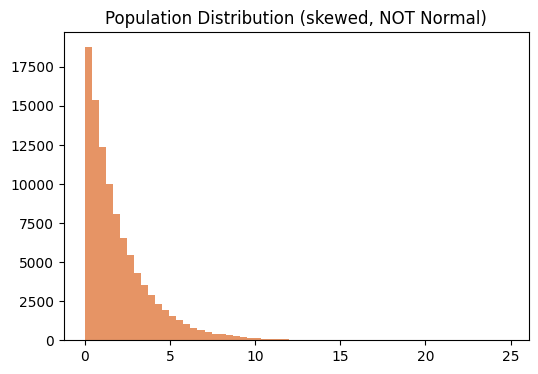

In [ ]:
skewed_population = rng.exponential(scale=2.0, size=100_000)

plt.figure(figsize=(6, 4))
plt.hist(skewed_population, bins=60, color="#E07A3F", alpha=0.8)
plt.title("Population Distribution (skewed, NOT Normal)")
plt.show()

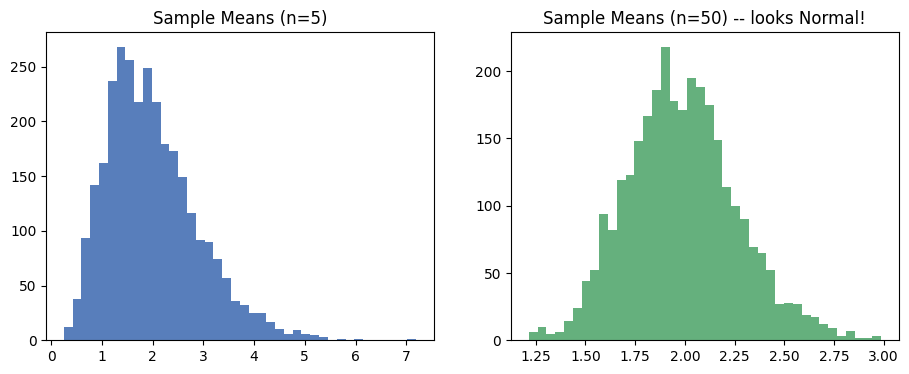

Skewness of raw population:      2.013
Skewness of sample means (n=5):  0.873
Skewness of sample means (n=50): 0.299


In [ ]:
def sample_means(population, sample_size, num_samples=3000):
    return np.array([
        rng.choice(population, size=sample_size, replace=True).mean()
        for _ in range(num_samples)
    ])

means_n5 = sample_means(skewed_population, sample_size=5)
means_n50 = sample_means(skewed_population, sample_size=50)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(means_n5, bins=40, color="#2E5EAA", alpha=0.8)
axes[0].set_title("Sample Means (n=5)")
axes[1].hist(means_n50, bins=40, color="#3E9C5D", alpha=0.8)
axes[1].set_title("Sample Means (n=50) -- looks Normal!")
plt.show()

print(f"Skewness of raw population:      {stats.skew(skewed_population):.3f}")
print(f"Skewness of sample means (n=5):  {stats.skew(means_n5):.3f}")
print(f"Skewness of sample means (n=50): {stats.skew(means_n50):.3f}")

As sample size grows, the skewness of the sample means shrinks toward zero — exactly what the Central Limit Theorem predicts, even though the original population was heavily skewed.

<a id="standard-error"></a>
# 4. Standard Error

In [3]:
sample = rng.normal(loc=170, scale=10, size=40)

sample_std = sample.std(ddof=1)
n = len(sample)
standard_error = sample_std / np.sqrt(n)

print(f"Sample standard deviation: {sample_std:.3f}")
print(f"Sample size: {n}")
print(f"Standard error: {standard_error:.3f}")

NameError: name 'rng' is not defined

In [ ]:
# Demonstrating that standard error shrinks as sample size grows
for n in [10, 40, 100, 400]:
    sample = rng.normal(loc=170, scale=10, size=n)
    se = sample.std(ddof=1) / np.sqrt(n)
    print(f"n={n:>4}: standard error = {se:.3f}")

<a id="normal"></a>
# 5. Normal Distribution and the Empirical Rule

In [ ]:
data = rng.normal(loc=100, scale=15, size=100_000)
mean, std = data.mean(), data.std()

within_1_std = np.mean((data >= mean - std) & (data <= mean + std)) * 100
within_2_std = np.mean((data >= mean - 2*std) & (data <= mean + 2*std)) * 100
within_3_std = np.mean((data >= mean - 3*std) & (data <= mean + 3*std)) * 100

print(f"Within 1 std dev: {within_1_std:.1f}% (empirical rule says ~68%)")
print(f"Within 2 std dev: {within_2_std:.1f}% (empirical rule says ~95%)")
print(f"Within 3 std dev: {within_3_std:.1f}% (empirical rule says ~99.7%)")

In [ ]:
# Using scipy.stats.norm to work directly with the theoretical Normal distribution
# What proportion of a Normal distribution falls within 1.96 standard deviations of the mean?
proportion = stats.norm.cdf(1.96) - stats.norm.cdf(-1.96)
print(f"Proportion within ±1.96 std dev: {proportion:.4f}")   # this is where the famous "1.96" in 95% CIs comes from!

<a id="confidence-intervals"></a>
# 6. Confidence Intervals

Let's build a 95% confidence interval for a population mean, using a single sample, then verify our formula by simulating many samples (recreating Figure 4 from the document).

In [ ]:
true_mean = 170

sample = rng.normal(loc=true_mean, scale=10, size=40)
sample_mean = sample.mean()
se = sample.std(ddof=1) / np.sqrt(len(sample))

# Using the t-distribution's critical value (more accurate than 1.96 for smaller samples)
confidence_level = 0.95
degrees_of_freedom = len(sample) - 1
critical_value = stats.t.ppf((1 + confidence_level) / 2, degrees_of_freedom)

margin_of_error = critical_value * se
lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

print(f"Sample mean: {sample_mean:.2f}")
print(f"95% Confidence Interval: ({lower_bound:.2f}, {upper_bound:.2f})")
print(f"True population mean ({true_mean}) is inside the interval: {lower_bound <= true_mean <= upper_bound}")

In [ ]:
# SciPy can compute this directly too
ci = stats.t.interval(0.95, degrees_of_freedom, loc=sample_mean, scale=se)
print("SciPy 95% CI:", ci)

In [ ]:
# Simulate 20 different samples and their 95% CIs, like Figure 4 in the document
n_intervals = 20
results = []

for i in range(n_intervals):
    s = rng.normal(loc=true_mean, scale=10, size=40)
    m = s.mean()
    se_i = s.std(ddof=1) / np.sqrt(len(s))
    ci_i = stats.t.interval(0.95, len(s) - 1, loc=m, scale=se_i)
    covers = ci_i[0] <= true_mean <= ci_i[1]
    results.append((m, ci_i[0], ci_i[1], covers))

covered_count = sum(r[3] for r in results)
print(f"{covered_count} out of {n_intervals} intervals captured the true mean ({covered_count/n_intervals:.0%})")
print("(With a 95% confidence level, we EXPECT roughly 95% of many such intervals to capture the true mean.)")

<a id="hypothesis-testing"></a>
# 7. Hypothesis Testing

Let's test a concrete claim: "the average height in our population is 170 cm" (H0), using only a sample.

In [ ]:
sample = rng.normal(loc=172, scale=10, size=50)   # true mean is actually 172, but we don't "know" that

# H0: population mean = 170
# H1: population mean != 170  (two-tailed test)
hypothesized_mean = 170

t_statistic, p_value = stats.ttest_1samp(sample, hypothesized_mean)

print(f"Sample mean: {sample.mean():.2f}")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value <= alpha:
    print(f"p-value ({p_value:.4f}) <= alpha ({alpha}) -> REJECT H0")
else:
    print(f"p-value ({p_value:.4f}) > alpha ({alpha}) -> FAIL TO REJECT H0")

**Common mistake:** Running this exact test with a small sample might sometimes fail to reject H0, even though we know (because we simulated it ourselves) that the true mean is actually 172, not 170. This isn't a bug — it's the reality of statistical inference under uncertainty. A Type II error (failing to detect a real, but perhaps small, effect) becomes more likely with smaller samples or a smaller true difference.

<a id="z-t-test"></a>
# 8. Z-Test and T-Test

## 8.1 Two-Sample T-Test

The most common real-world use case: comparing the means of two independent groups — for example, an A/B test.

In [ ]:
# Simulate an A/B test: version A vs version B of a webpage, measuring time spent (seconds)
group_a = rng.normal(loc=120, scale=20, size=60)    # control
group_b = rng.normal(loc=128, scale=20, size=60)    # new version, slightly higher average

t_statistic, p_value = stats.ttest_ind(group_a, group_b)

print(f"Group A mean: {group_a.mean():.2f}")
print(f"Group B mean: {group_b.mean():.2f}")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
conclusion = "statistically significant difference" if p_value <= alpha else "no statistically significant difference"
print(f"\nConclusion at alpha={alpha}: {conclusion}")

## 8.2 One-Sample Z-Test (Manual)

SciPy doesn't include a dedicated z-test function (since the t-test is nearly always preferred in practice), but here's how you'd compute one manually, for a case where the population standard deviation IS known.

In [ ]:
# Suppose we somehow know the true population standard deviation is 10
known_population_std = 10
sample = rng.normal(loc=172, scale=10, size=100)
hypothesized_mean = 170

z_statistic = (sample.mean() - hypothesized_mean) / (known_population_std / np.sqrt(len(sample)))
p_value_z = 2 * (1 - stats.norm.cdf(abs(z_statistic)))   # two-tailed p-value

print(f"Z-statistic: {z_statistic:.3f}")
print(f"P-value: {p_value_z:.4f}")

<a id="chi-square"></a>
# 9. Chi-Square Test

Testing whether two categorical variables are related — e.g. does preferred product category depend on city?

In [ ]:
# Rows = cities, columns = product categories -- values are observed counts
observed = pd.DataFrame({
    "Electronics": [50, 30, 20],
    "Furniture":   [20, 40, 25],
    "Clothing":    [30, 25, 45],
}, index=["Lahore", "Karachi", "Islamabad"])

print(observed)

chi2_statistic, p_value, degrees_of_freedom, expected_counts = stats.chi2_contingency(observed)

print(f"\nChi-square statistic: {chi2_statistic:.3f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value <= alpha:
    print("There IS a statistically significant association between city and product category.")
else:
    print("No statistically significant association found between city and product category.")

<a id="anova"></a>
# 10. ANOVA (Analysis of Variance)

Comparing the means of three or more groups at once — e.g. average test scores across four different teachers.

In [ ]:
teacher_a_scores = rng.normal(75, 8, 30)
teacher_b_scores = rng.normal(78, 8, 30)
teacher_c_scores = rng.normal(74, 8, 30)
teacher_d_scores = rng.normal(85, 8, 30)   # noticeably higher

f_statistic, p_value = stats.f_oneway(teacher_a_scores, teacher_b_scores, teacher_c_scores, teacher_d_scores)

print(f"F-statistic: {f_statistic:.3f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05
if p_value <= alpha:
    print("At least one teacher's average score is significantly different from the others.")
else:
    print("No statistically significant difference found among the teachers' average scores.")

**Common mistake:** Running many separate t-tests (one for every pair of teachers) instead of a single ANOVA. Each individual t-test carries its own small chance of a false positive (Type I error), and running many of them multiplies that risk across the whole analysis. ANOVA tests all groups together in one single, appropriately calibrated test.

<a id="corr-vs-causation"></a>
# 11. Correlation vs Causation

Let's simulate the classic "ice cream sales vs drowning incidents" example, where a hidden confounding variable (temperature) drives both.

In [ ]:
days = 200
temperature = rng.normal(loc=25, scale=8, size=days)   # the HIDDEN confounding variable

# Both ice cream sales AND drownings increase with temperature, with some added randomness
ice_cream_sales = 20 + 3 * temperature + rng.normal(0, 15, days)
drowning_incidents = 1 + 0.15 * temperature + rng.normal(0, 1.5, days)
drowning_incidents = np.clip(drowning_incidents, 0, None)   # can't have negative drownings

correlation = np.corrcoef(ice_cream_sales, drowning_incidents)[0, 1]
print(f"Correlation between ice cream sales and drownings: {correlation:.3f}")

plt.figure(figsize=(6, 4))
plt.scatter(ice_cream_sales, drowning_incidents, alpha=0.6, color="#2E5EAA")
plt.xlabel("Ice Cream Sales")
plt.ylabel("Drowning Incidents")
plt.title(f"Correlation = {correlation:.2f} (but NEITHER causes the other!)")
plt.show()

In [ ]:
# The REAL relationship: both are driven by temperature
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(temperature, ice_cream_sales, alpha=0.6, color="#E07A3F")
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("Ice Cream Sales")
axes[0].set_title(f"Correlation = {np.corrcoef(temperature, ice_cream_sales)[0,1]:.2f}")

axes[1].scatter(temperature, drowning_incidents, alpha=0.6, color="#3E9C5D")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("Drowning Incidents")
axes[1].set_title(f"Correlation = {np.corrcoef(temperature, drowning_incidents)[0,1]:.2f}")
plt.tight_layout()
plt.show()

Both ice cream sales and drownings are strongly correlated with temperature — the true underlying driver. Their correlation with *each other* is a side effect of both being correlated with this hidden, confounding variable, not a sign that one causes the other.

<a id="practice"></a>
# Practice Exercises

## Level 1 — Basic
1. Simulate a population with `rng.normal(loc=60, scale=12, size=50000)`. Draw a single random sample of size 30 and compare its mean to the true population mean.
2. For a sample of size 25 with sample standard deviation 8, compute the standard error by hand (formula, not a function).
3. Using `scipy.stats.norm.cdf`, find the proportion of a Normal distribution that falls within ±1 standard deviation of the mean, and compare it to the empirical rule's "68%".

## Level 2 — Applied
4. Simulate 3000 sample means from `rng.exponential(scale=3.0, size=100000)` using a sample size of 2, and again using a sample size of 100. Plot both histograms side by side and compare their shapes.
5. Build a 90% confidence interval (instead of 95%) for a sample of size 35 drawn from `rng.normal(loc=80, scale=15, size=35)`. (Hint: change the `confidence_level` and see how the interval's width changes compared to a 95% CI.)
6. Run a two-sample t-test comparing `rng.normal(60, 10, 40)` and `rng.normal(65, 10, 40)`. State your conclusion at `alpha = 0.05`.

## Level 3 — ML-oriented Challenge
7. You're comparing two versions of a recommendation algorithm's click-through rate (CTR), measured on samples of users: `algorithm_a = rng.normal(0.045, 0.01, 200)` and `algorithm_b = rng.normal(0.052, 0.01, 200)`. Run a two-sample t-test, report the p-value, and state whether the difference is statistically significant at `alpha = 0.05`. Then explain (in a markdown cell) why statistical significance alone might not be enough to justify switching algorithms in production.
8. Create a contingency table testing whether device type (`"Mobile"`, `"Desktop"`, `"Tablet"`) is associated with whether a user completes a purchase (`"Yes"`, `"No"`) using made-up counts of your choice. Run a chi-square test and interpret the result.

### Solutions

In [ ]:
#1st Problem
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
population = rng.normal(loc=60, scale=12, size=50000)
sample = rng.choice(population, size=30, replace= True)

print(f"TRUE population mean: {population.mean():.2f}")
print(f"TRUE Sample mean: {sample.mean():.2f}")


TRUE population mean: 60.04
TRUE Sample mean: 58.06


In [ ]:
#2nd Problem
sample_std = sample.std(ddof=1)
n = len(sample)
standard_error = (sample_std) / np.sqrt(n)
print(f"Standard Error : {standard_error:.2f}")


Standard Error : 2.07


In [ ]:
#3rd Problem 
from scipy import stats
proprotion = scipy.stats.norm.cdf(1.96) - scipy.stats.norm.cdf(-1.96)
print(proportion)

In [ ]:
#4th Problem
skewed_population = rng.exponential(scale=3.0, size=100000)
def sample_means(population, sample_size, num_samples=3000):
    return np.array([
        rng.choice(population, size=sample_size, replace=True).mean()
        for _ in range(num_samples)
    ])

means_n5 = sample_means(skewed_population, sample_size=2)
means_n50 = sample_means(skewed_population, sample_size=100)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(means_n5, bins=40, color="#2E5EAA", alpha=0.8)
axes[0].set_title("Sample Means (n=5)")
axes[1].hist(means_n50, bins=40, color="#3E9C5D", alpha=0.8)
axes[1].set_title("Sample Means (n=50) -- looks Normal!")
plt.show()


In [ ]:
#5th Problem
sample = rng.normal(loc=80, scale=15, size=35)
sample_mean = sample.mean()
degrees_of_freedom = len(sample) - 1
ci = stats.t.interval(0.90, degrees_of_freedom, loc=sample_mean, scale=se)
print("SciPy 90% CI:", ci)

In [ ]:
#6th Problem
sample1 = rng.normal(60, 10, 40)
sample2 = rng.normal(65, 10, 40)
t_statistic, p_value = stats.ttest_ind(sample1, sample2)

print(f"Group A mean: {sample1.mean():.2f}")
print(f"Group B mean: {sample2.mean():.2f}")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
conclusion = "statistically significant difference" if p_value <= alpha else "no statistically significant difference"
print(f"\nConclusion at alpha={alpha}: {conclusion}")

In [ ]:
#7th Problem
group_a = rng.normal(0.045, 0.01, 200)   
group_b = rng.normal(0.052, 0.01, 200)    

t_statistic, p_value = stats.ttest_ind(group_a, group_b)

print(f"Group A mean: {group_a.mean():.2f}")
print(f"Group B mean: {group_b.mean():.2f}")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
conclusion = "statistically significant difference" if p_value <= alpha else "no statistically significant difference"
print(f"\nConclusion at alpha={alpha}: {conclusion}")

In [ ]:
#8th Problem
import pandas as pd
Product = pd.DataFrame(
    { 
        "name" : ["Mobile", "Desktop","Tablet"],
    },
    index = ["yes","no","yes"]
)
print(Product)

chi2_statistic, p_value, degrees_of_freedom, expected_counts = stats.chi2_contingency(Product)

print(f"\nChi-square statistic: {chi2_statistic:.3f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value: {p_value:.4f}")


        name
yes   Mobile
no   Desktop
yes   Tablet


**Why statistical significance alone isn't enough:** a statistically significant result only tells us the difference is unlikely to be pure chance — it says nothing about whether the difference is *large enough to matter* in practice (the "effect size"), nor about other costs of switching (engineering effort, risk, user disruption). A tiny CTR improvement might be statistically significant with a large enough sample, yet not worth the cost of deploying a new algorithm.

---
**Well done!** You've now implemented, in code, every inferential statistics concept from the companion document — from the Central Limit Theorem all the way to hypothesis testing and the correlation-vs-causation trap. This statistical foundation underlies how you'll evaluate, compare, and trust every Machine Learning model you build from here on.